# EDA Analysis

This notebook uses `data/clean/08_wages_ai_analysis_panel.csv`.

**Research question:** How does occupational AI exposure affect wages across all occupations in Australia over 2020–2024, and how has that effect changed year by year?

**EDA goals:**
- Understand the distribution and missingness of key variables
- Examine wage and AI exposure patterns by occupation type and year
- Visualise the core relationship: does the AI exposure–wage slope change across years?


## 1. Load Data and Setup

Load the panel and set display/plot options used in the rest of the notebook.

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

np.random.seed(42)
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

project_root = Path.cwd()
if project_root.name == 'code':
    project_root = project_root.parent

panel_path = project_root / 'data' / 'clean' / '08_wages_ai_analysis_panel.csv'
if not panel_path.exists():
    raise FileNotFoundError(f'Could not find dataset at {panel_path.resolve()}')

raw = pd.read_csv(panel_path)
print(f'Shape: {raw.shape}')
print(f'Years: {sorted(raw["year"].unique())}')
print(f'People: {raw["person_id"].nunique():,}')


Shape: (63744, 21)
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
People: 18,227


- `Rows: 63,744` — total person-year observations in the analysis sample
- `Columns: 21` — identifiers, occupation, AI exposure, wages, controls, year dummies, and interaction terms
- `People: 18,227` — unique individuals in the panel
- `Years: [2020–2024]` — five survey waves
2020 is the omitted base year in the regression


In [25]:
raw.head(10)

,person_id,year,occ_code,occ_major_group,white_collar,blue_collar,ai_exposure,annual_wage,log_wage,sex,age,state,edu,yr_2021,ai_x_yr2021,yr_2022,ai_x_yr2022,yr_2023,ai_x_yr2023,yr_2024,ai_x_yr2024
0,100005,2020,54.0000,5.0000,0,1,0.4924,8.0000,2.0794,2.0000,35.0000,6.0000,8.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000
1,100010,2020,NaN,NaN,0,0,NaN,5.0000,1.6094,2.0000,55.0000,2.0000,1.0000,0,NaN,0,NaN,0,NaN,0,NaN
2,100015,2020,59.0000,5.0000,0,1,0.2408,8.0000,2.0794,2.0000,63.0000,1.0000,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000
3,100016,2020,13.0000,1.0000,1,0,0.2649,9.0000,2.1972,1.0000,38.0000,1.0000,3.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000
4,100018,2020,39.0000,3.0000,1,0,-0.2450,7.0000,1.9459,2.0000,59.0000,5.0000,4.0000,0,-0.0000,0,-0.0000,0,-0.0000,0,-0.0000
5,100019,2020,55.0000,5.0000,0,1,0.4811,9.0000,2.1972,1.0000,63.0000,5.0000,1.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000
6,100020,2020,26.0000,2.0000,1,0,0.2315,9.0000,2.1972,1.0000,33.0000,5.0000,5.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000
7,100021,2020,54.0000,5.0000,0,1,0.4924,5.0000,1.6094,2.0000,28.0000,5.0000,3.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000
8,100026,2020,NaN,NaN,0,0,NaN,5.0000,1.6094,2.0000,29.0000,3.0000,8.0000,0,NaN,0,NaN,0,NaN,0,NaN
9,100027,2020,24.0000,2.0000,1,0,0.3056,7.0000,1.9459,1.0000,27.0000,3.0000,8.0000,0,0.0000,0,0.0000,0,0.0000,0,0.0000


- Each row is one person in one year observation
- `person_id` — unique respondent identifier used to track individuals across years
- `occ_code` — 2-digit ANZSCO occupation code
- `white_collar` / `blue_collar` are derived from this
- `ai_exposure` — occupation-level AI exposure score (fixed across time, not person-specific)
- `annual_wage` / `log_wage` — raw and log-transformed wage
- `yr_2021`–`yr_2024` show as 0 here because the first 13,355 rows are all 2020 observations — correct by design


## 2. Data Profile

Check variable types, missing values, and basic coverage before analysis.

In [26]:
# Variable types and missingness
profile = pd.DataFrame({
    'dtype': raw.dtypes,
    'non_null': raw.notna().sum(),
    'pct_missing': (raw.isna().mean() * 100).round(2),
    'n_unique': raw.nunique(),
})
print(profile.to_string())


                   dtype  non_null  pct_missing  n_unique
person_id          int64     63744       0.0000     18227
year               int64     63744       0.0000         5
occ_code         float64     53066      16.7500        51
occ_major_group  float64     53066      16.7500         8
white_collar       int64     63744       0.0000         2
blue_collar        int64     63744       0.0000         2
ai_exposure      float64     52830      17.1200        43
annual_wage      float64     63744       0.0000        10
log_wage         float64     63744       0.0000        10
sex              float64     63744       0.0000         2
age              float64     63744       0.0000        85
state            float64     63744       0.0000         8
edu              float64     63744       0.0000         8
yr_2021            int64     63744       0.0000         2
ai_x_yr2021      float64     52830      17.1200        44
yr_2022            int64     63744       0.0000         2
ai_x_yr2022   

- `dtype` — variable type; `object` = string, `int64`/`float64` = numeric
- `pct_missing` — `ai_exposure` is missing for ~17% of rows (occupation code could not be matched to AIOE); all other key variables should be close to 0%
- `n_unique` — number of distinct values;
- `person_id` unique count equals the number of individuals;
- `occ_code` unique count equals the number of distinct occupations in the sample
- Year dummies (`yr_2021`–`yr_2024`) have only 2 unique values (0 and 1) — expected


In [27]:
# Sample composition
print('Occupation type:')
print(f"  White collar: {(raw['white_collar']==1).sum():,} ({(raw['white_collar']==1).mean():.1%})")
print(f"  Blue collar:  {(raw['blue_collar']==1).sum():,} ({(raw['blue_collar']==1).mean():.1%})")
print(f"  Unclassified: {(raw['white_collar']+raw['blue_collar']==0).sum():,}")
print()
print('AI exposure coverage:')
print(f"  Has ai_exposure: {raw['ai_exposure'].notna().sum():,} ({raw['ai_exposure'].notna().mean():.1%})")
print(f"  Missing:         {raw['ai_exposure'].isna().sum():,} ({raw['ai_exposure'].isna().mean():.1%})")
print()
print('Rows by year:')
print(raw.groupby('year').size().rename('n_obs').to_string())


Occupation type:
  White collar: 35,185 (55.2%)
  Blue collar:  17,881 (28.1%)
  Unclassified: 10,678

AI exposure coverage:
  Has ai_exposure: 52,830 (82.9%)
  Missing:         10,914 (17.1%)

Rows by year:
year
2020    13355
2021    13209
2022    10421
2023    12959
2024    13800


- White collar (ANZSCO 1–4) accounts for ~55% of observations; blue collar (ANZSCO 5–8) ~28%; the remainder are unclassified or missing occupation codes
- `ai_exposure` coverage ~83% — the missing 17% are automatically excluded from interaction terms (`ai_x_yr{t}` is set to NA)
- Row counts vary by year (2022 has the fewest); this reflects HILDA survey attrition and wave-specific sample composition


## 3. Wage Distributions

Examine the distribution of log wages and annual wages, overall and by year.

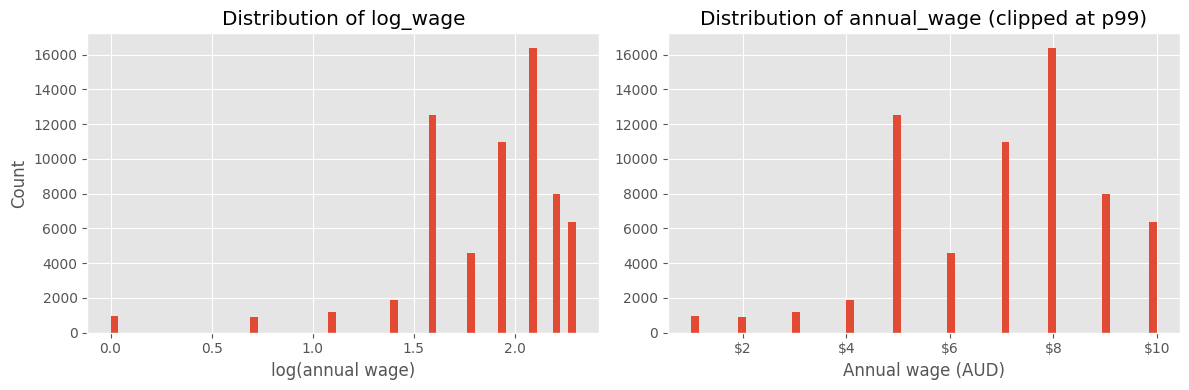

        log_wage  annual_wage
count 63744.0000   63744.0000
mean      1.8910       7.0210
std       0.3840       1.9930
min       0.0000       1.0000
25%       1.6090       5.0000
50%       1.9460       7.0000
75%       2.0790       8.0000
max       2.3030      10.0000


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw['log_wage'].dropna(), bins=60, edgecolor='none')
axes[0].set_title('Distribution of log_wage')
axes[0].set_xlabel('log(annual wage)')
axes[0].set_ylabel('Count')

axes[1].hist(raw['annual_wage'].dropna().clip(upper=raw['annual_wage'].quantile(0.99)), bins=60, edgecolor='none')
axes[1].set_title('Distribution of annual_wage (clipped at p99)')
axes[1].set_xlabel('Annual wage (AUD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(raw[['log_wage', 'annual_wage']].describe().round(3).to_string())


- Left (`log_wage`): approximately normal distribution — consistent with the log-normal wage assumption; suitable as the regression dependent variable
- Right (`annual_wage`, clipped at p99): strongly right-skewed with high earners in the tail 
  It confirms that log transformation is appropriate
- The mean and std from `describe()` provide a baseline wage level reference (e^11 ≈ AUD 60,000)

log_wage by year:
       mean  median    std
year                      
2020 1.8682  1.9459 0.4039
2021 1.8813  1.9459 0.3920
2022 1.9767  2.0794 0.3172
2023 1.8715  1.9459 0.3963
2024 1.8774  1.9459 0.3825


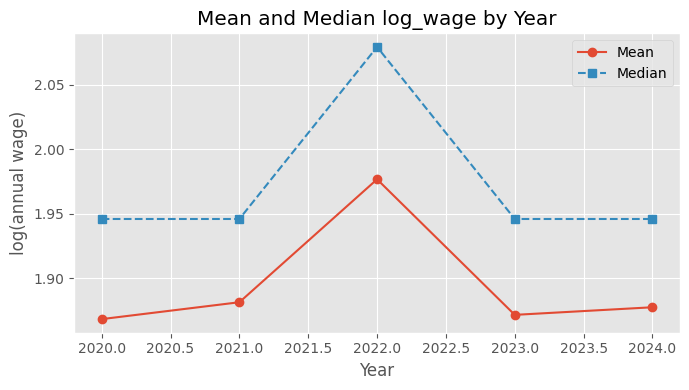

In [29]:
# Mean log wage by year — tracks aggregate wage trend
yr_wage = raw.groupby('year')['log_wage'].agg(['mean','median','std']).round(4)
print('log_wage by year:')
print(yr_wage.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yr_wage.index, yr_wage['mean'], marker='o', label='Mean')
ax.plot(yr_wage.index, yr_wage['median'], marker='s', linestyle='--', label='Median')
ax.set_title('Mean and Median log_wage by Year')
ax.set_xlabel('Year')
ax.set_ylabel('log(annual wage)')
ax.legend()
plt.tight_layout()
plt.show()


- The upward trend in mean log wage reflects nominal wage growth over 2020–2024 (includes inflation)
- Mean and median tracking closely together indicates no single extreme group is distorting the aggregate trend
- This common time trend is absorbed by the year dummies in the regression
- β_t captures the additional divergence attributable to AI exposure beyond the aggregate trend


## 4. AI Exposure Distribution

Examine `ai_exposure` across occupations, collar types, and years. This is the key treatment variable.

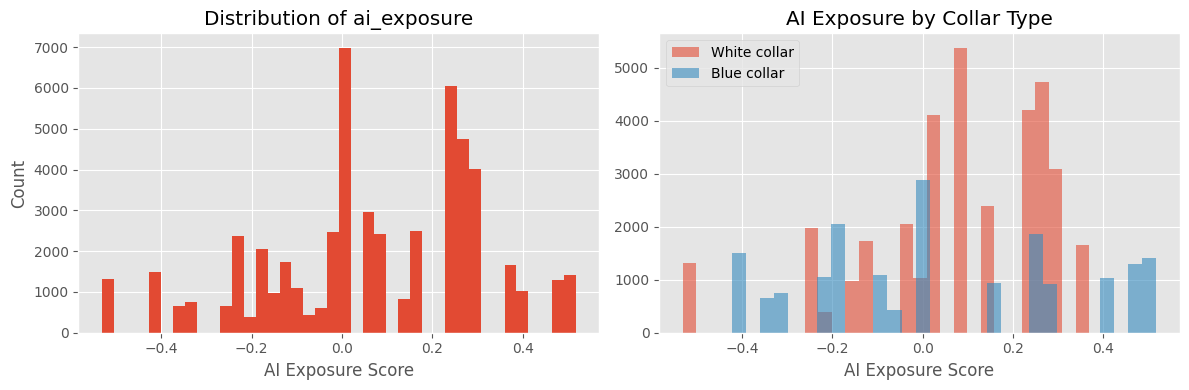

                   mean  median  count
occ_major_group                       
1.0000           0.1913  0.2649   7820
2.0000           0.2149  0.2336  14271
3.0000          -0.2203 -0.2336   6455
4.0000          -0.0355 -0.0169   6453
5.0000           0.3782  0.4099   6276
6.0000           0.0647  0.0121   4043
7.0000          -0.1991 -0.1840   3220
8.0000          -0.2795 -0.3519   4292


In [30]:
ai = raw.dropna(subset=['ai_exposure'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ai['ai_exposure'], bins=40, edgecolor='none')
axes[0].set_title('Distribution of ai_exposure')
axes[0].set_xlabel('AI Exposure Score')
axes[0].set_ylabel('Count')

wc = ai[ai['white_collar']==1]['ai_exposure']
bc = ai[ai['blue_collar']==1]['ai_exposure']
axes[1].hist(wc, bins=30, alpha=0.6, label='White collar', edgecolor='none')
axes[1].hist(bc, bins=30, alpha=0.6, label='Blue collar', edgecolor='none')
axes[1].set_title('AI Exposure by Collar Type')
axes[1].set_xlabel('AI Exposure Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(ai.groupby('occ_major_group')['ai_exposure'].agg(['mean','median','count']).round(4).to_string())


- Left: `ai_exposure` is right-skewed — most occupations cluster at low exposure, with a long tail of high-exposure cognitive occupations
- Right: white-collar occupations have higher AI exposure on average than blue-collar — consistent with expectations; knowledge-work tasks are more amenable to AI than manual tasks
- The table below breaks down mean exposure by 2-digit ANZSCO major group, identifying which occupation clusters are most exposed
- `ai_exposure` is time-invariant (occupation-level), so it acts as a cross-sectional treatment intensity variable in the regression


## 5. Control Variable Distributions

Profile `sex`, `age`, `state`, and `edu` — the controls used in the regression.

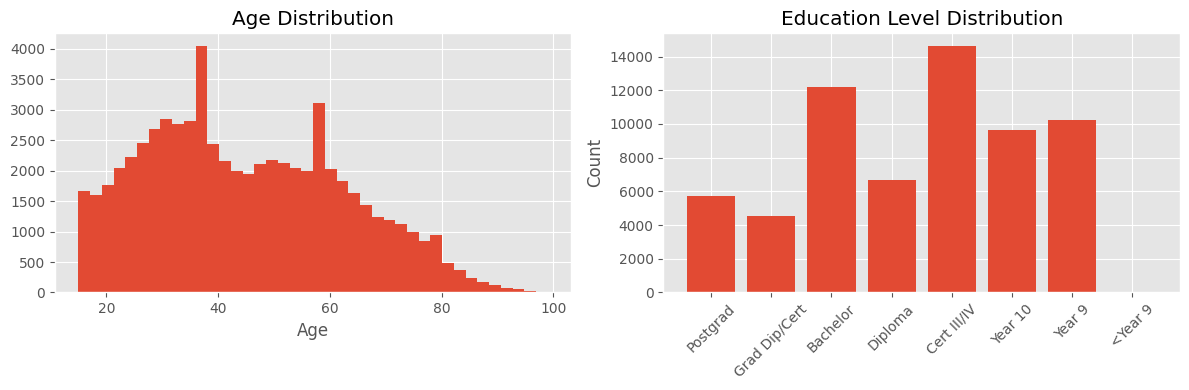

Sex: {2.0: 32616, 1.0: 31128} (1=male, 2=female)


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw['age'].dropna().hist(bins=40, ax=axes[0], edgecolor='none')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

edu_counts = raw['edu'].value_counts().sort_index()
edu_labels = {
    1:'Postgrad', 2:'Grad Dip/Cert', 3:'Bachelor',
    4:'Diploma', 5:'Cert III/IV', 6:'Year 12',
    7:'Year 11', 8:'Year 10', 9:'Year 9', 10:'<Year 9'
}
axes[1].bar(edu_counts.index.map(lambda x: edu_labels.get(int(x), str(x))), edu_counts.values)
axes[1].set_title('Education Level Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Sex:', raw['sex'].value_counts().to_dict(), '(1=male, 2=female)')


- **Age**: concentrated between 25–55 years, consistent with the prime working-age labour force; few extreme values
- **Education**: sample skews towards Bachelor degree and Year 12 completers, reflecting HILDA's urban employed respondent base
- `edu` coding: 1 = postgraduate, 10 = did not complete Year 11 — lower values indicate higher qualifications
- Sex composition (1 = male, 2 = female) is used to control for the gender wage gap


## 6. Core Pattern: AI Exposure × Year

This is the visual preview of the time-varying coefficient model. 
If β_t changes over years, we expect the slope of ai_exposure on log_wage to shift year by year.

We bin ai_exposure into deciles and plot mean log_wage by bin for each year.

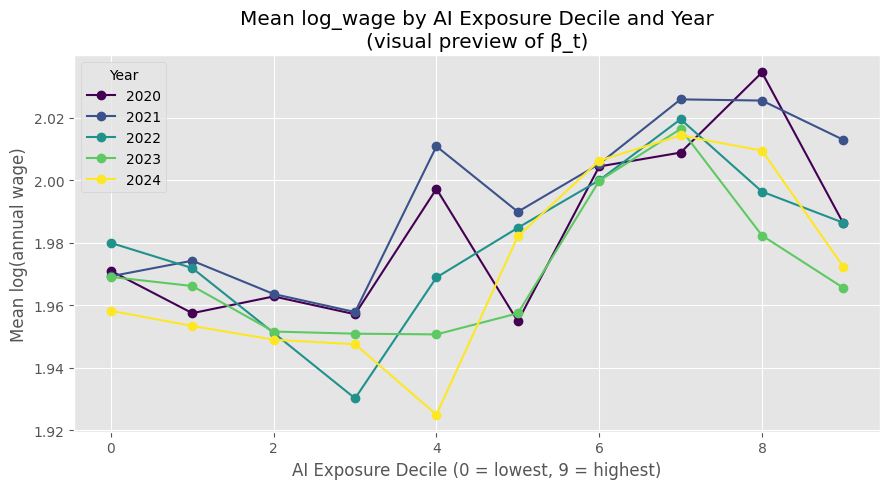

In [32]:
ai = raw.dropna(subset=['ai_exposure', 'log_wage']).copy()
ai['ai_decile'] = pd.qcut(ai['ai_exposure'], q=10, labels=False)

yr_ai = (
    ai.groupby(['year', 'ai_decile'])['log_wage']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
years = sorted(yr_ai['year'].unique())
colors = plt.cm.viridis([i / (len(years)-1) for i in range(len(years))])

for yr, col in zip(years, colors):
    sub = yr_ai[yr_ai['year']==yr]
    ax.plot(sub['ai_decile'], sub['log_wage'], marker='o', label=str(int(yr)), color=col)

ax.set_title('Mean log_wage by AI Exposure Decile and Year\n(visual preview of β_t)')
ax.set_xlabel('AI Exposure Decile (0 = lowest, 9 = highest)')
ax.set_ylabel('Mean log(annual wage)')
ax.legend(title='Year')
plt.tight_layout()
plt.show()


- Horizontal axis: `ai_exposure` decile (0 = lowest exposure, 9 = highest); vertical axis: mean log wage for that group
- Each line represents one year; if the slope differs across years, the wage return to AI exposure is changing over time
- A steeper slope in later years → positive β_t (rising wage premium for high-AI occupations)
- A flatter or negative slope in later years → negative β_t (AI substitution suppressing wages)
- Note: individual fixed effects and controls are not applied here — this is a raw descriptive preview


Pearson correlation: ai_exposure vs log_wage, by year
year
2020   0.0499
2021   0.0675
2022   0.0387
2023   0.0296
2024   0.0599


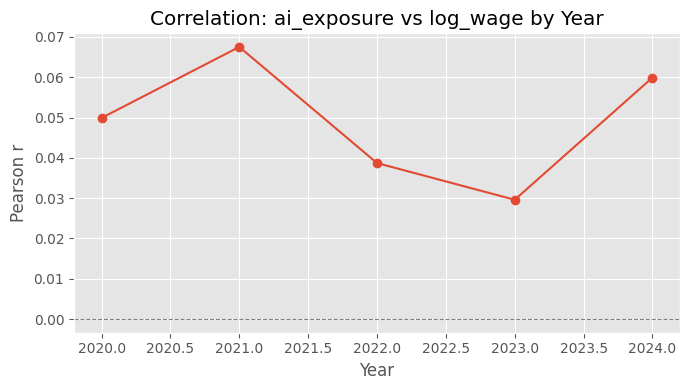

In [33]:
# Year-by-year correlation between ai_exposure and log_wage
corr_by_year = (
    ai.groupby('year')
    .apply(lambda g: g['ai_exposure'].corr(g['log_wage']))
    .rename('corr_ai_logwage')
    .round(4)
)
print('Pearson correlation: ai_exposure vs log_wage, by year')
print(corr_by_year.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
corr_by_year.plot(marker='o', ax=ax)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Correlation: ai_exposure vs log_wage by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Pearson r')
plt.tight_layout()
plt.show()


- Each point is the Pearson correlation between `ai_exposure` and `log_wage` for that year, computed across all observations
- An increasing correlation over time suggests the wage premium for AI-exposed occupations is growing (complementarity)
- A declining or negative trend suggests AI is compressing wages in exposed occupations (substitution)
- This is a descriptive preview of β_t's direction; individual fixed effects and controls are not applied here


## 7. EDA Summary

Key observations from exploratory analysis, relevant to model specification.

In [34]:
summary = {
    'total_obs': len(raw),
    'unique_people': raw['person_id'].nunique(),
    'years': sorted(raw['year'].unique()),
    'ai_exposure_coverage': f"{raw['ai_exposure'].notna().mean():.1%}",
    'white_collar_share': f"{(raw['white_collar']==1).mean():.1%}",
    'blue_collar_share': f"{(raw['blue_collar']==1).mean():.1%}",
    'log_wage_mean': round(raw['log_wage'].mean(), 3),
    'log_wage_std': round(raw['log_wage'].std(), 3),
    'ai_exposure_mean': round(raw['ai_exposure'].mean(), 4),
    'ai_exposure_std': round(raw['ai_exposure'].std(), 4),
}
for k, v in summary.items():
    print(f'{k:30s}: {v}')


total_obs                     : 63744
unique_people                 : 18227
years                         : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
ai_exposure_coverage          : 82.9%
white_collar_share            : 55.2%
blue_collar_share             : 28.1%
log_wage_mean                 : 1.891
log_wage_std                  : 0.384
ai_exposure_mean              : 0.0702
ai_exposure_std               : 0.2398


- `total_obs` — total person-year observations in the final analysis sample
- `unique_people` — number of distinct individuals (cross-sectional dimension of the panel)
- `years` — sample coverage; 2020 is the base year (omitted in regression)
- `ai_exposure_coverage` — share of observations with a valid AI exposure score (~83%); the remainder are excluded from interaction terms
- `white/blue_collar_share` — white collar (ANZSCO 1–4) 55%, blue collar (ANZSCO 5–8) 28%
- `log_wage_mean/std` — baseline wage level; e^11 ≈ AUD 60,000
- `ai_exposure_mean/std` — centred/normalised score; negative values indicate low-AI occupations relative to the sample mean
